# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data

In [2]:
df = pd.read_parquet('./data/pp-complete.parquet')
df.head()

,price,date,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type
0,166500,1995-11-22,CM23 4PA,D,Y,F,19,MAYFLOWER GARDENS,BISHOP'S STORTFORD,BISHOP'S STORTFORD,EAST HERTFORDSHIRE,HERTFORDSHIRE,A
1,59000,1995-09-27,L12 0AY,D,N,L,7,TRENT CLOSE,LIVERPOOL,LIVERPOOL,LIVERPOOL,MERSEYSIDE,A
2,118000,1995-12-15,SL3 8XX,D,N,F,24,SOUTHWOLD SPUR,SLOUGH,SLOUGH,SLOUGH,SLOUGH,A
3,48500,1995-01-27,CV12 8TF,S,N,F,5,CHELTENHAM CLOSE,BEDWORTH,BEDWORTH,NUNEATON AND BEDWORTH,WARWICKSHIRE,A
4,27500,1995-04-20,SY11 1HP,S,N,F,105,BEATRICE STREET,OSWESTRY,OSWESTRY,OSWESTRY,SHROPSHIRE,A


In [3]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
first_date = df['date'].min()
df['passed'] = (df['date'] - first_date).dt.days

df.drop(columns=['date'], inplace=True)

df.head()

,price,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed
0,166500,CM23 4PA,D,Y,F,19,MAYFLOWER GARDENS,BISHOP'S STORTFORD,BISHOP'S STORTFORD,EAST HERTFORDSHIRE,HERTFORDSHIRE,A,1995,11,325
1,59000,L12 0AY,D,N,L,7,TRENT CLOSE,LIVERPOOL,LIVERPOOL,LIVERPOOL,MERSEYSIDE,A,1995,9,269
2,118000,SL3 8XX,D,N,F,24,SOUTHWOLD SPUR,SLOUGH,SLOUGH,SLOUGH,SLOUGH,A,1995,12,348
3,48500,CV12 8TF,S,N,F,5,CHELTENHAM CLOSE,BEDWORTH,BEDWORTH,NUNEATON AND BEDWORTH,WARWICKSHIRE,A,1995,1,26
4,27500,SY11 1HP,S,N,F,105,BEATRICE STREET,OSWESTRY,OSWESTRY,OSWESTRY,SHROPSHIRE,A,1995,4,109


# Functions

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Все аргументы в градусах, возвращает расстояние в километрах.
    """
    # переводим в радианы
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    Δφ = np.radians(lat2 - lat1)
    Δλ = np.radians(lon2 - lon1)

    a = np.sin(Δφ/2)**2 + np.cos(φ1)*np.cos(φ2)*np.sin(Δλ/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    R = 6371.0  # средний радиус Земли в км

    return R * c

def evaluate_model(model):
  y_pred = model.predict(X_test)
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse) 
  r2 = r2_score(y_test, y_pred)

  print(f"Mean Absolute Error (MAE): {mae:.4f}")
  print(f"Mean Squared Error (MSE): {mse:.4f}")
  print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
  print(f"R-squared (R²): {r2:.4f}")

def find_outliers_z_score(data, feature, left=3, right=3, log_scale=False, year_col='year'):
    """
    Находит выбросы в данных по каждому году, используя метод z-отклонений.
    Args:
        data (pandas.DataFrame): набор данных
        feature (str): имя признака, на основе которого происходит поиск выбросов
        left (float, optional): количество стандартных отклонений в левую сторону
        right (float, optional): количество стандартных в правую сторону
        log_scale (bool, optional): режим логарифмирования
        year_col (str, optional): имя колонки с годом

    Returns:
        pandas.DataFrame: выбросы по всем годам
        pandas.DataFrame: очищенные данные по всем годам
    """
    outliers_list = []
    cleaned_list = []
    for year, group in data.groupby(year_col):
        if log_scale:
            x = np.log(group[feature] + 1)
        else:
            x = group[feature]
        mu = x.mean()
        sigma = x.std()
        bound_lower = mu - left * sigma
        bound_upper = mu + right * sigma
        outliers = group[(x < bound_lower) | (x > bound_upper)]
        cleaned = group[(x >= bound_lower) & (x <= bound_upper)]
        outliers_list.append(outliers)
        cleaned_list.append(cleaned)
    outliers_all = pd.concat(outliers_list)
    cleaned_all = pd.concat(cleaned_list)
    return outliers_all, cleaned_all

# Feature Engineering

In [5]:
outliers_df, df = find_outliers_z_score(df, 'price', left=2, right=2, log_scale=True, year_col='year')
outliers_df

,price,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed
32,217500,RG42 6AR,D,N,F,HORSESHOE HOUSE,WARFIELD STREET,WARFIELD,BRACKNELL,BRACKNELL FOREST,BRACKNELL FOREST,A,1995,9,261
47,15000,ST5 2BU,T,N,F,49,HEATH STREET,NEWCASTLE,NEWCASTLE,NEWCASTLE-UNDER-LYME,STAFFORDSHIRE,A,1995,6,180
59,10000,DE11 9QU,S,N,F,48,HALL STREET,CHURCH GRESLEY,SWADLINCOTE,SOUTH DERBYSHIRE,DERBYSHIRE,A,1995,11,304
70,15750,SS1 1PU,F,N,L,96A,QUEENS ROAD,SOUTHEND-ON-SEA,SOUTHEND-ON-SEA,SOUTHEND-ON-SEA,SOUTHEND-ON-SEA,A,1995,3,75
77,15700,PL5 2PP,T,N,F,108,BIGGIN HILL,PLYMOUTH,PLYMOUTH,PLYMOUTH,DEVON,A,1995,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30124045,1280000,W2 1BF,F,N,L,3,MERCHANT SQUARE,,LONDON,CITY OF WESTMINSTER,GREATER LONDON,A,2025,1,10963
30124173,65000,S80 2HP,T,N,F,124,POTTER STREET,,WORKSOP,BASSETLAW,NOTTINGHAMSHIRE,A,2025,1,10974
30124180,1320000,NW8 0PX,F,N,L,45,MARLBOROUGH PLACE,,LONDON,CITY OF WESTMINSTER,GREATER LONDON,A,2025,1,10988
30124265,1100000,HA9 8HA,S,N,F,16,WEMBLEY PARK DRIVE,,WEMBLEY,BRENT,GREATER LONDON,A,2025,1,10963


In [6]:
district_counts = df['district'].value_counts().reset_index()
district_counts.columns = ['district', 'count']

# Получаем список названий district, где число упоминаний < 100
low_count_districts = district_counts[district_counts['count'] < 100]['district'].tolist()

# Удаляем эти районы из основного датафрейма
df = df[~df['district'].isin(low_count_districts)]

df['median_price_all_type'] = df.groupby(['type', 'old_new', 'duration', 'ppd_type', 'district', 'year', 'month'])['price'].transform('median')
df.head(10)

,price,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed,median_price_all_type
0,166500,CM23 4PA,D,Y,F,19,MAYFLOWER GARDENS,BISHOP'S STORTFORD,BISHOP'S STORTFORD,EAST HERTFORDSHIRE,HERTFORDSHIRE,A,1995,11,325,124500.0
1,59000,L12 0AY,D,N,L,7,TRENT CLOSE,LIVERPOOL,LIVERPOOL,LIVERPOOL,MERSEYSIDE,A,1995,9,269,55000.0
2,118000,SL3 8XX,D,N,F,24,SOUTHWOLD SPUR,SLOUGH,SLOUGH,SLOUGH,SLOUGH,A,1995,12,348,106000.0
3,48500,CV12 8TF,S,N,F,5,CHELTENHAM CLOSE,BEDWORTH,BEDWORTH,NUNEATON AND BEDWORTH,WARWICKSHIRE,A,1995,1,26,48000.0
4,27500,SY11 1HP,S,N,F,105,BEATRICE STREET,OSWESTRY,OSWESTRY,OSWESTRY,SHROPSHIRE,A,1995,4,109,43000.0
5,114000,SE24 0DH,S,N,F,13,BRANTWOOD ROAD,LONDON,LONDON,LAMBETH,GREATER LONDON,A,1995,6,180,94000.0
6,46000,TS10 2DJ,S,N,F,2,MALCOLM GROVE,REDCAR,REDCAR,LANGBAURGH-ON-TEES,CLEVELAND,A,1995,9,262,44500.0
7,52500,SN2 2SY,S,N,F,11,MARIGOLD CLOSE,SWINDON,SWINDON,THAMESDOWN,THAMESDOWN,A,1995,5,131,55250.0
8,19000,PO32 6EP,T,N,F,17,CLARENCE ROAD,EAST COWES,EAST COWES,ISLE OF WIGHT,ISLE OF WIGHT,A,1995,10,302,38000.0
9,67500,SE18 2DH,T,N,F,75,HIGHMEAD,LONDON,LONDON,GREENWICH,GREATER LONDON,A,1995,11,320,55000.0


In [7]:
big_city_set = {city.upper() for city in [
    'London', 'Birmingham', 'Leeds', 'Glasgow', 'Sheffield', 'Manchester',
    'Edinburgh', 'Liverpool', 'Bristol', 'Cardiff', 'Coventry', 'Belfast',
    'Nottingham', 'Brighton', 'Newcastle', 'Plymouth'
]}

def is_big_city(city):
    # Сравниваем город в верхнем регистре
    return 1 if city.upper() in big_city_set else 0

df['is_big_city'] = df['town_city'].apply(is_big_city)

In [8]:
# Определим периоды кризисов в виде списков
crisis_periods = [
    (2008, 1, 2009, 12),  # Мировой финансовый кризис
    (2020, 1, 2020, 12)   # Пандемия COVID-19
]

df['is_crysis'] = 0

# Векторизованно добавляем 1 для строк, попадающих в периоды кризисов
for start_year, start_month, end_year, end_month in crisis_periods:
    # Условие для попадания в кризисный период
    is_in_period = (
        (df['year'] > start_year) | ((df['year'] == start_year) & (df['month'] >= start_month))
    ) & (
        (df['year'] < end_year) | ((df['year'] == end_year) & (df['month'] <= end_month))
    )
    
    # Обновляем значение 'is_crysis' для строк, попадающих в кризис
    df.loc[is_in_period, 'is_crysis'] = 1

df.head(5)

,price,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed,median_price_all_type,is_big_city,is_crysis
0,166500,CM23 4PA,D,Y,F,19,MAYFLOWER GARDENS,BISHOP'S STORTFORD,BISHOP'S STORTFORD,EAST HERTFORDSHIRE,HERTFORDSHIRE,A,1995,11,325,124500.0,0,0
1,59000,L12 0AY,D,N,L,7,TRENT CLOSE,LIVERPOOL,LIVERPOOL,LIVERPOOL,MERSEYSIDE,A,1995,9,269,55000.0,1,0
2,118000,SL3 8XX,D,N,F,24,SOUTHWOLD SPUR,SLOUGH,SLOUGH,SLOUGH,SLOUGH,A,1995,12,348,106000.0,0,0
3,48500,CV12 8TF,S,N,F,5,CHELTENHAM CLOSE,BEDWORTH,BEDWORTH,NUNEATON AND BEDWORTH,WARWICKSHIRE,A,1995,1,26,48000.0,0,0
4,27500,SY11 1HP,S,N,F,105,BEATRICE STREET,OSWESTRY,OSWESTRY,OSWESTRY,SHROPSHIRE,A,1995,4,109,43000.0,0,0


In [9]:
postcode_coords = pd.read_csv('./data/postcode_lat_long.csv')

df = df.merge(postcode_coords, on='postcode', how='left')

df.rename(columns={'latitude': 'latitude', 'longitude': 'longitude'}, inplace=True)
del postcode_coords

df.drop(columns=['postcode'], inplace=True)
df.dropna(subset=["latitude", "longitude"], inplace=True)

df.head()

,price,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed,median_price_all_type,is_big_city,is_crysis,latitude,longitude
0,166500,D,Y,F,19,MAYFLOWER GARDENS,BISHOP'S STORTFORD,BISHOP'S STORTFORD,EAST HERTFORDSHIRE,HERTFORDSHIRE,A,1995,11,325,124500.0,0,0,51.895390,0.156180
1,59000,D,N,L,7,TRENT CLOSE,LIVERPOOL,LIVERPOOL,LIVERPOOL,MERSEYSIDE,A,1995,9,269,55000.0,1,0,53.432800,-2.909600
2,118000,D,N,F,24,SOUTHWOLD SPUR,SLOUGH,SLOUGH,SLOUGH,SLOUGH,A,1995,12,348,106000.0,0,0,51.502114,-0.551257
3,48500,S,N,F,5,CHELTENHAM CLOSE,BEDWORTH,BEDWORTH,NUNEATON AND BEDWORTH,WARWICKSHIRE,A,1995,1,26,48000.0,0,0,52.478075,-1.447600
4,27500,S,N,F,105,BEATRICE STREET,OSWESTRY,OSWESTRY,OSWESTRY,SHROPSHIRE,A,1995,4,109,43000.0,0,0,52.832861,-2.965928


In [10]:
#TODO Расчет расстояния до ближайшего крупного города
#TODO Расчет населения/числа продаж города
#TODO Добавить дискреты is_big_city/is_crysis
#TODO Добавить сопутствующие экономические метрики: ср.зарплата/инфляция/безработица

In [11]:
city_coords = pd.read_csv('./data/city_lat_long.csv')

df = df.merge(city_coords, on='town_city', how='left')

df.rename(columns={'city_lat': 'city_lat', 'city_lon': 'city_lon'}, inplace=True)
del city_coords

df.drop(columns=['town_city'], inplace=True)
df.dropna(subset=["city_lat", "city_lon"], inplace=True)

df.head()

,price,type,old_new,duration,PAON SAON,street,locality,district,county,ppd_type,year,month,passed,median_price_all_type,is_big_city,is_crysis,latitude,longitude,city_lat,city_lon
0,166500,D,Y,F,19,MAYFLOWER GARDENS,BISHOP'S STORTFORD,EAST HERTFORDSHIRE,HERTFORDSHIRE,A,1995,11,325,124500.0,0,0,51.895390,0.156180,51.867628,0.163196
1,59000,D,N,L,7,TRENT CLOSE,LIVERPOOL,LIVERPOOL,MERSEYSIDE,A,1995,9,269,55000.0,1,0,53.432800,-2.909600,53.407199,-2.991680
2,118000,D,N,F,24,SOUTHWOLD SPUR,SLOUGH,SLOUGH,SLOUGH,A,1995,12,348,106000.0,0,0,51.502114,-0.551257,51.503427,-0.574872
3,48500,S,N,F,5,CHELTENHAM CLOSE,BEDWORTH,NUNEATON AND BEDWORTH,WARWICKSHIRE,A,1995,1,26,48000.0,0,0,52.478075,-1.447600,52.479283,-1.466320
4,27500,S,N,F,105,BEATRICE STREET,OSWESTRY,OSWESTRY,SHROPSHIRE,A,1995,4,109,43000.0,0,0,52.832861,-2.965928,52.860310,-3.054820


In [12]:
# Считаем расстояние
df['dist_km'] = haversine(
    df['city_lat'], df['city_lon'],
    df['latitude'], df['longitude']
)

df[['latitude','longitude','city_lat','city_lon','dist_km']].head()

,latitude,longitude,city_lat,city_lon,dist_km
0,51.895390,0.156180,51.867628,0.163196,3.124343
1,53.432800,-2.909600,53.407199,-2.991680,6.139023
2,51.502114,-0.551257,51.503427,-0.574872,1.641050
3,52.478075,-1.447600,52.479283,-1.466320,1.274898
4,52.832861,-2.965928,52.860310,-3.054820,6.704670


In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=12, random_state=42)
df["cluster"] = kmeans.fit_predict(df[["latitude", "longitude"]])
df["cluster"] = df["cluster"].astype("category")

df.head()

,price,type,old_new,duration,PAON SAON,street,locality,district,county,ppd_type,...,passed,median_price_all_type,is_big_city,is_crysis,latitude,longitude,city_lat,city_lon,dist_km,cluster
0,166500,D,Y,F,19,MAYFLOWER GARDENS,BISHOP'S STORTFORD,EAST HERTFORDSHIRE,HERTFORDSHIRE,A,...,325,124500.0,0,0,51.895390,0.156180,51.867628,0.163196,3.124343,1
1,59000,D,N,L,7,TRENT CLOSE,LIVERPOOL,LIVERPOOL,MERSEYSIDE,A,...,269,55000.0,1,0,53.432800,-2.909600,53.407199,-2.991680,6.139023,3
2,118000,D,N,F,24,SOUTHWOLD SPUR,SLOUGH,SLOUGH,SLOUGH,A,...,348,106000.0,0,0,51.502114,-0.551257,51.503427,-0.574872,1.641050,9
3,48500,S,N,F,5,CHELTENHAM CLOSE,BEDWORTH,NUNEATON AND BEDWORTH,WARWICKSHIRE,A,...,26,48000.0,0,0,52.478075,-1.447600,52.479283,-1.466320,1.274898,0
4,27500,S,N,F,105,BEATRICE STREET,OSWESTRY,OSWESTRY,SHROPSHIRE,A,...,109,43000.0,0,0,52.832861,-2.965928,52.860310,-3.054820,6.704670,3


In [14]:
print(df.columns.tolist())

['price', 'type', 'old_new', 'duration', 'PAON SAON', 'street', 'locality', 'district', 'county', 'ppd_type', 'year', 'month', 'passed', 'median_price_all_type', 'is_big_city', 'is_crysis', 'latitude', 'longitude', 'city_lat', 'city_lon', 'dist_km', 'cluster']


# Data Preparation

In [15]:
df.drop(columns=['PAON SAON'], inplace=True)

In [16]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = [
    'type', 'old_new', 'duration', 'ppd_type',
    'street', 'locality', 'district', 'county'
]

ordinal_encoder = OrdinalEncoder()
df[ordinal_cols] = ordinal_encoder.fit_transform(df[ordinal_cols])
df.head()

,price,type,old_new,duration,street,locality,district,county,ppd_type,year,...,passed,median_price_all_type,is_big_city,is_crysis,latitude,longitude,city_lat,city_lon,dist_km,cluster
0,166500,0.0,1.0,0.0,191049.0,1796.0,133.0,57.0,0.0,1995,...,325,124500.0,0,0,51.895390,0.156180,51.867628,0.163196,3.124343,1
1,59000,0.0,0.0,1.0,295600.0,12052.0,222.0,69.0,0.0,1995,...,269,55000.0,1,0,53.432800,-2.909600,53.407199,-2.991680,6.139023,3
2,118000,0.0,0.0,0.0,265827.0,18505.0,339.0,96.0,0.0,1995,...,348,106000.0,0,0,51.502114,-0.551257,51.503427,-0.574872,1.641050,9
3,48500,3.0,0.0,0.0,57539.0,1388.0,281.0,117.0,0.0,1995,...,26,48000.0,0,0,52.478075,-1.447600,52.479283,-1.466320,1.274898,0
4,27500,3.0,0.0,0.0,20191.0,15356.0,285.0,95.0,0.0,1995,...,109,43000.0,0,0,52.832861,-2.965928,52.860310,-3.054820,6.704670,3


In [17]:
# TODO Add encoding for categorical features
# TODO Add scaling for numerical features

In [18]:
from sklearn.model_selection import train_test_split

# Define features and target variable
X = df.drop(columns=['price'])
y = df['price']

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (22936852, 20), X_test shape: (5734213, 20)
y_train shape: (22936852,), y_test shape: (5734213,)


In [19]:
del df, X, y

In [20]:
from xgboost import XGBRegressor

XGBR_model = XGBRegressor(
    enable_categorical=True,
)

XGBR_model.fit(X_train, y_train)
evaluate_model(XGBR_model)

Mean Absolute Error (MAE): 45678.1562
Mean Squared Error (MSE): 6027719168.0000
Root Mean Squared Error (RMSE): 77638.3872
R-squared (R²): 0.7515


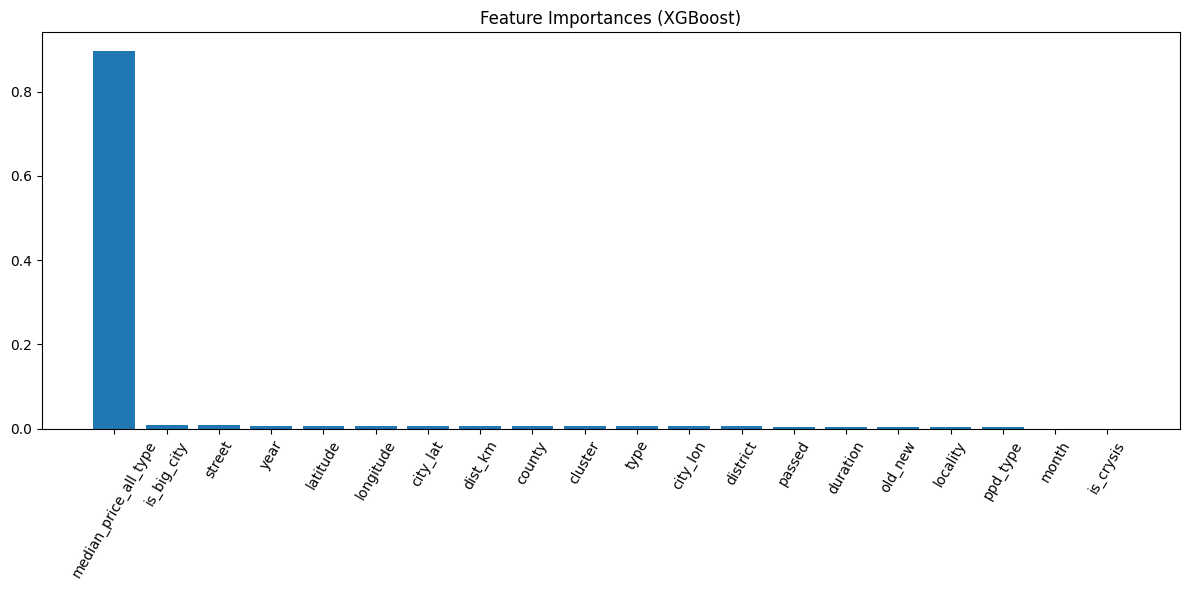

In [21]:
import matplotlib.pyplot as plt

# Get feature importances from the trained XGBRegressor model
importances = XGBR_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (XGBoost)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=60)
plt.tight_layout()
plt.show()

In [22]:
raise KeyboardInterrupt

KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import RandomForestRegressor

RF_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1
)

RF_model.fit(X_train, y_train)
evaluate_model(RF_model)

Mean Absolute Error (MAE): 64956.9049
Mean Squared Error (MSE): 464865266537.7163
Root Mean Squared Error (RMSE): 681810.2863
R-squared (R²): 0.4289


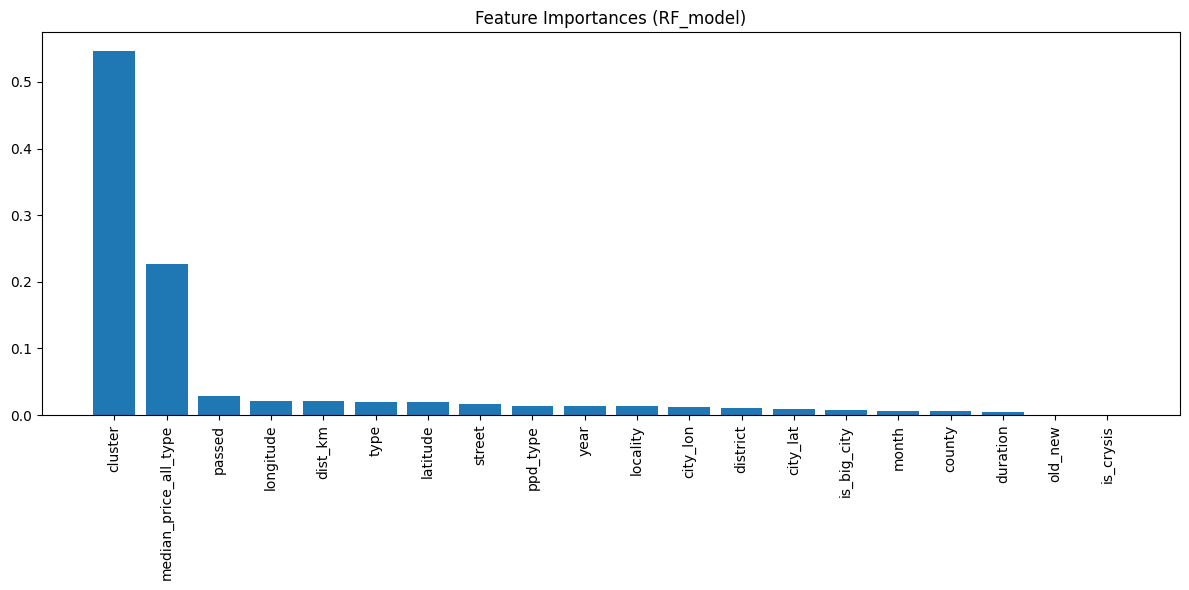

In [ ]:
import matplotlib.pyplot as plt

# Get feature importances from the trained XGBRegressor model
importances = RF_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (RF_model)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score


def objective(trial):

    n_estimators1 = trial.suggest_int("n_estimators", 4000, 6000, step=500)
    # L1 regularization weight.
    alpha1 = trial.suggest_float("alpha", 1e-8, 1e-5, log=True)
    # sampling ratio for training data.
    subsample1 = trial.suggest_float("subsample", 0.3, 0.5)
    # sampling according to each tree.
    colsample_bytree1 = trial.suggest_float("colsample_bytree", 0.35, 0.56)
    # maximum depth of the tree, signifies complexity of the tree.
    max_depth1 = trial.suggest_int("max_depth", 3, 7, step=2)
    # minimum child weight, larger the term more conservative the tree.
    min_child_weight1 = trial.suggest_int("min_child_weight", 1, 3)
    # learning rate
    learning_rate1 =  trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    # defines how selective algorithm is.
    gamma1 = trial.suggest_float("gamma", 1e-3, 1e-1, log=True)
       

        
    

    xgb_regressor = XGBRegressor(n_estimators = n_estimators1,alpha=alpha1,subsample=subsample1,colsample_bytree=colsample_bytree1,
                           max_depth=max_depth1,min_child_weight =min_child_weight1,learning_rate=learning_rate1,gamma=gamma1,eval_metric = 'mae',
                           random_state =1, enable_categorical=True)

    ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0) #ShuffleSplit will help you to keep distributions of training data and folds similar)
    score = cross_val_score(xgb_regressor, X_train, y_train, scoring= make_scorer(mean_absolute_error),  cv=ss)
    score = score.mean()
    return score


sampler = TPESampler(seed=42) # create a seed for the sampler for reproducibility
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=30, n_jobs=1) # n_jobs = -1 will use all cores

[I 2025-05-13 18:13:15,492] A new study created in memory with name: no-name-ef58ad9c-071d-4487-9329-efaccfc08b09


[W 2025-05-13 18:13:39,607] Trial 0 failed with parameters: {'n_estimators': 4500, 'alpha': 7.114476009343412e-06, 'subsample': 0.446398788362281, 'colsample_bytree': 0.4757182816813777, 'max_depth': 3, 'min_child_weight': 1, 'learning_rate': 0.00013066739238053285, 'gamma': 0.05399484409787434} because of the following error: MemoryError((19247825,), dtype('int64')).
Traceback (most recent call last):
  File "c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Tema\AppData\Local\Temp\ipykernel_23664\1963810842.py", line 35, in objective
    score = cross_val_score(xgb_regressor, X_train, y_train, scoring= make_scorer(mean_absolute_error),  cv=ss)
  File "c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
  File "c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 68

MemoryError: Unable to allocate 147. MiB for an array with shape (19247825,) and data type int64